In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("../data/raw/raw_data.csv")
df.head()

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
def compare_imputation_strategies(df, feature, constant_val=-999):
    """
    Compares 4 different states of a feature: Original, Mean imputed, 
    Median imputed, and Constant Value imputed.
    Plots a 2x2 grid for easy visual comparison.
    """
    # 1. Create temporary imputed series
    original = df[feature].dropna()
    mean_imputed = df[feature].fillna(df[feature].mean())
    median_imputed = df[feature].fillna(df[feature].median())
    constant_imputed = df[feature].fillna(constant_val)

    # 2. Set up the matplotlib figure (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Imputation Strategy Comparison for: {feature}', fontsize=16)

    # Top-Left: Original
    sns.histplot(original, kde=True, bins=40, color="blue", ax=axes[0, 0])
    axes[0, 0].set_title('1. Original Distribution (Drop NA)')

    # Top-Right: Mean Imputed
    sns.histplot(mean_imputed, kde=True, bins=40, color="green", ax=axes[0, 1])
    axes[0, 1].set_title('2. Mean Imputation')

    # Bottom-Left: Median Imputed
    sns.histplot(median_imputed, kde=True, bins=40, color="orange", ax=axes[1, 0])
    axes[1, 0].set_title('3. Median Imputation')

    # Bottom-Right: Constant Imputed
    sns.histplot(constant_imputed, kde=True, bins=40, color="red", ax=axes[1, 1])
    axes[1, 1].set_title(f'4. Constant Imputation ({constant_val})')

    plt.tight_layout()
    plt.show()

# =====================================================================
# TEST THE FUNCTION
# =====================================================================
# Just call this line with any numeric feature you want to test!
# Let's test it on a variable with FEW nulls (e.g., ~3% nulls)
# compare_imputation_strategies(df, "avg_cur_bal")

# Let's test it on a variable with MANY nulls (e.g., ~47% nulls)
print("Running comparison tool for 'il_util'...")
compare_imputation_strategies(df, "il_util", constant_val=-100)

Visualizing TOP 35 columns with most missing data...


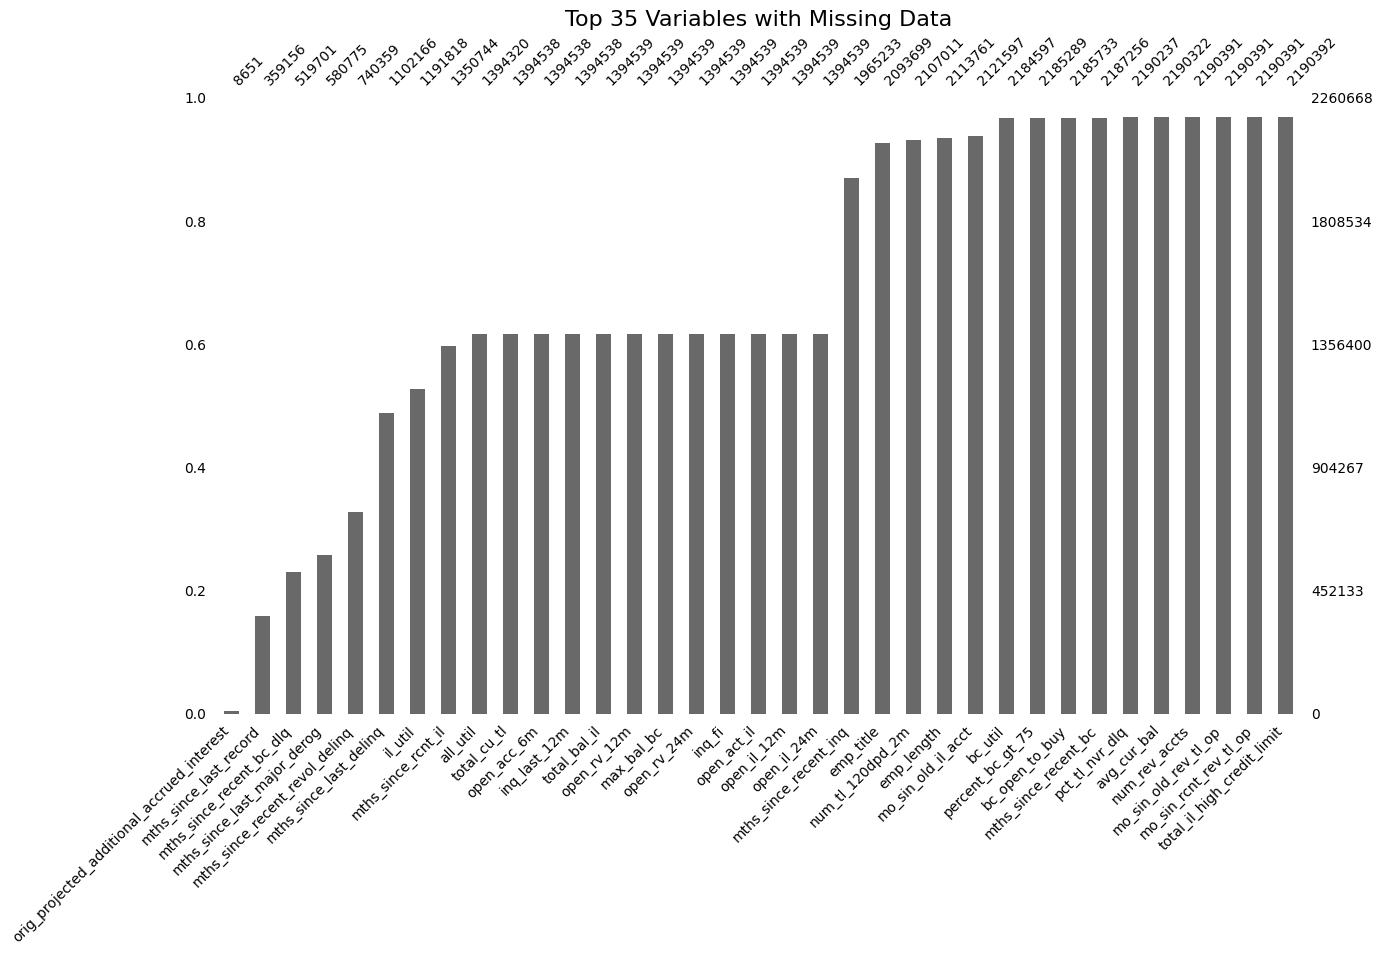


--- Testing Mean Imputation on 'il_util' (47% missing) ---


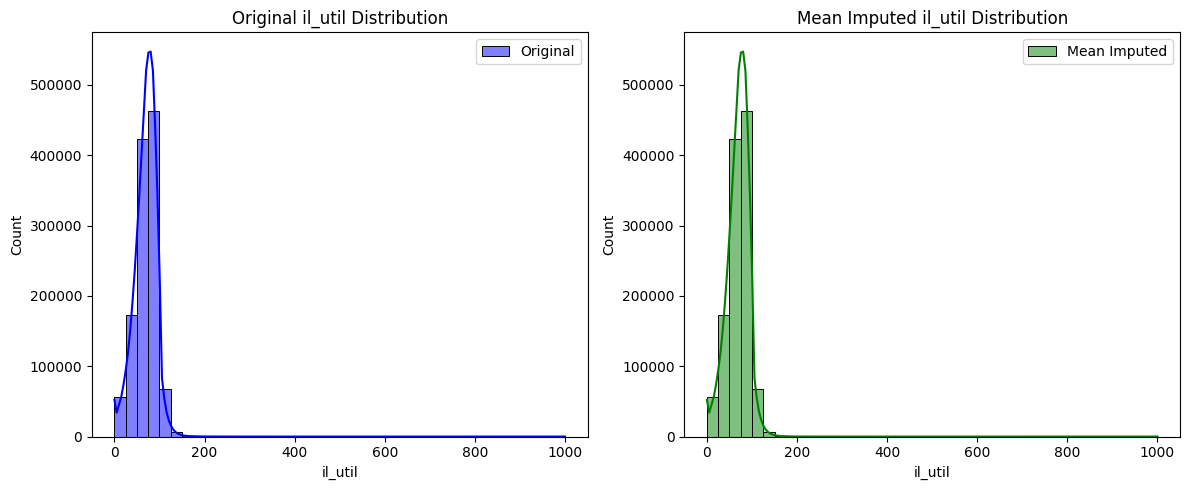


--- Testing Median Imputation on 'il_util' (47% missing) ---


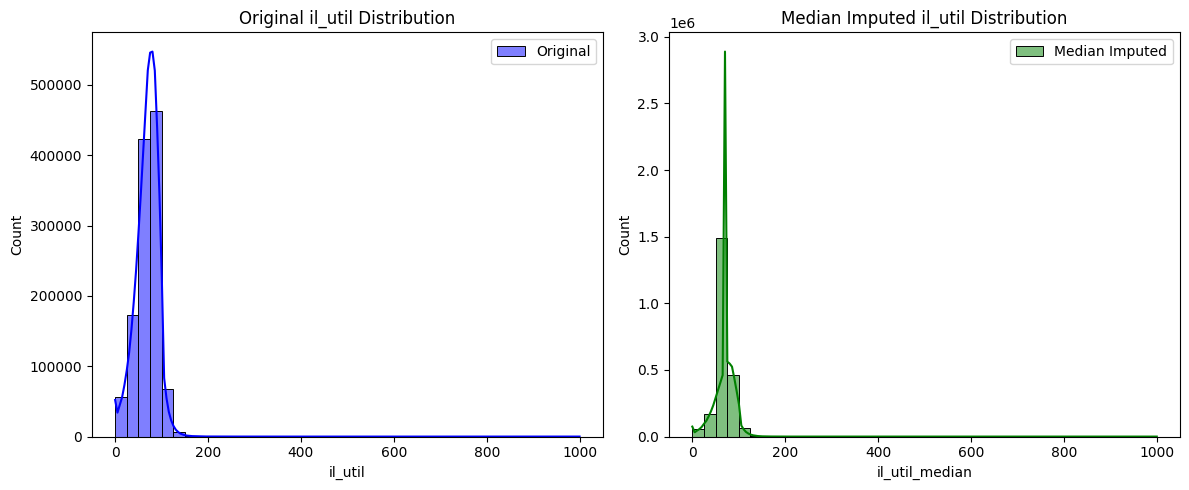

In [ ]:
# =====================================================================
# STEP 0: VISUALIZE MISSING DATA (TOP 35)
# =====================================================================
print("Visualizing TOP 35 columns with most missing data...")
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_cols = missing_percent[missing_percent > 0].sort_values(ascending=False)
top_missing_cols = missing_cols.head(35).index

plt.figure(figsize=(14, 8))
msno.bar(df[top_missing_cols], figsize=(14, 8), fontsize=10)
plt.title("Top 35 Variables with Missing Data", fontsize=16)
plt.show()

# =====================================================================
# STEP 1: DROP DATA LEAKAGE & IRRELEVANT COLUMNS
# =====================================================================
print("Dropping Data Leakage and irrelevant columns...")
columns_to_drop = [
    # Identifiers and text
    'member_id', 'url', 'desc', 'title',
    # Hardship flags and details (Data Leakage)
    'hardship_reason', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 
    'payment_plan_start_date', 'hardship_type', 'hardship_status', 'hardship_start_date', 
    'deferral_term', 'hardship_amount', 'hardship_dpd', 'hardship_loan_status', 
    'hardship_length', 'hardship_end_date', 'hardship_flag',
    # Settlement flags and details (Data Leakage)
    'settlement_status', 'debt_settlement_flag_date', 'settlement_term', 
    'settlement_percentage', 'settlement_date', 'settlement_amount', 'debt_settlement_flag',
    # Joint App features (Too many nulls)
    'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'sec_app_inq_last_6mths', 
    'sec_app_num_rev_accts', 'sec_app_open_acc', 'sec_app_earliest_cr_line', 
    'sec_app_fico_range_high', 'sec_app_mort_acc', 'sec_app_open_act_il', 
    'sec_app_fico_range_low', 'sec_app_collections_12_mths_ex_med', 
    'sec_app_chargeoff_within_12_mths', 'revol_bal_joint', 'verification_status_joint', 
    'dti_joint', 'annual_inc_joint',
    # Post-origination metrics / Recoveries (Data Leakage)
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 
    'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low'
]

df = df.drop(columns=columns_to_drop, errors='ignore')
df = df.dropna(subset=['loan_status'])

# =====================================================================
# STEP 2: DATA IMPUTATION
# =====================================================================
print("Applying imputation strategies...")

# Utility function for visual benchmarking (kept for your EDA process)
def compare_imputation_strategies(dataframe, feature, constant_val=-999):
    original = dataframe[feature].dropna()
    mean_imputed = dataframe[feature].fillna(dataframe[feature].mean())
    median_imputed = dataframe[feature].fillna(dataframe[feature].median())
    constant_imputed = dataframe[feature].fillna(constant_val)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Imputation Strategy Comparison for: {feature}', fontsize=16)
    sns.histplot(original, kde=True, bins=40, color="blue", ax=axes[0, 0]).set_title('1. Original Distribution')
    sns.histplot(mean_imputed, kde=True, bins=40, color="green", ax=axes[0, 1]).set_title('2. Mean Imputation')
    sns.histplot(median_imputed, kde=True, bins=40, color="orange", ax=axes[1, 0]).set_title('3. Median Imputation')
    sns.histplot(constant_imputed, kde=True, bins=40, color="red", ax=axes[1, 1]).set_title(f'4. Constant Imputation ({constant_val})')
    plt.tight_layout()
    plt.show()

# 2.1 Drop features with extremely high missingness (> 30%) to avoid variance distortion
high_null_cols = ['il_util', 'mths_since_last_record', 'mths_since_recent_bc_dlq', 'mths_since_last_major_derog'] 
df = df.drop(columns=high_null_cols, errors='ignore')

# 2.2 Impute low-missingness numerical features with Median (robust to outliers)
low_null_num_cols = ['avg_cur_bal', 'bc_util', 'tot_coll_amt', 'tot_cur_bal'] # You can append more to this list
for col in low_null_num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# 2.3 Impute low-missingness categorical/ordinal features with Mode
low_null_cat_cols = ['emp_length'] 
for col in low_null_cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# =====================================================================
# STEP 3: ENCODING CATEGORICAL VARIABLES
# =====================================================================
print("Encoding categorical variables...")

# 3.1 Ordinal Encoding for Risk Grades
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
if 'grade' in df.columns:
    df['grade_encoded'] = df['grade'].map(grade_mapping)
    df = df.drop(columns=['grade', 'sub_grade'], errors='ignore')

# 3.2 One-Hot Encoding for Nominal Variables (drop_first=True avoids Dummy Trap)
nominal_columns = ['home_ownership', 'verification_status', 'purpose', 'application_type']
nominal_columns_exist = [col for col in nominal_columns if col in df.columns]
df = pd.get_dummies(df, columns=nominal_columns_exist, drop_first=True)

# =====================================================================
# STEP 4: NORMALIZING SKEWED DATA
# =====================================================================
print("Normalizing highly skewed features...")
# Using log1p to handle right-skewed income data safely (handles zeros)
if 'annual_inc' in df.columns:
    df['annual_inc_log'] = np.log1p(df['annual_inc'])
    df = df.drop(columns=['annual_inc'])

# =====================================================================
# STEP 5: STANDARDIZING NUMERICAL DATA
# =====================================================================
print("Standardizing numerical features...")

# Select only numerical columns (int64, float64), ignoring booleans from get_dummies
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Ensure we don't scale the target variable if it's already numeric
numerical_cols = [col for col in numerical_cols if col != 'loan_status']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Data processing complete! Final dataset shape:", df.shape)
display(df.head())